In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
import torch
import torch.nn as nn
import warnings
warnings.filterwarnings('ignore')

print("Imports ready!")

Imports ready!


In [2]:
OUTPUT_DIR = Path(r'C:\Users\taylo\hyperwind_now\data\processed')
MODEL_DIR  = Path(r'C:\Users\taylo\hyperwind_now\models')

# DFW domain
LAT = np.array([32.2, 32.6, 33.0, 33.2, 33.4])
LON = np.array([-97.8, -97.6, -97.4, -97.2, -97.0, -96.8, -96.6, -96.4])
DX  = 111000 * np.cos(np.radians(32.8)) * 0.25
DY  = 111000 * 0.25

# ASOS station locations (lat, lon)
STATIONS = {
    "DFW": (32.90, -97.04),
    "DAL": (32.85, -96.85),
    "FTW": (32.82, -97.36),
    "AFW": (32.99, -97.32),
    "DTO": (33.20, -97.18),
    "RBD": (32.68, -96.87),
}

# EnKF config
N_ENSEMBLE  = 50    # number of ensemble members
OBS_ERROR   = 0.5   # observation error std (m/s) — ASOS accuracy
BG_ERROR    = 1.5   # background error std (m/s) — ERA5 uncertainty

print(f"Domain    : {len(LAT)} lat x {len(LON)} lon")
print(f"Stations  : {len(STATIONS)}")
print(f"Ensemble  : {N_ENSEMBLE} members")
print(f"Obs error : {OBS_ERROR} m/s")
print(f"Bg error  : {BG_ERROR} m/s")

Domain    : 5 lat x 8 lon
Stations  : 6
Ensemble  : 50 members
Obs error : 0.5 m/s
Bg error  : 1.5 m/s


In [3]:
def build_observation_operator(stations, lat, lon):
    """
    H matrix: maps gridded wind field to station locations.
    
    For each station, finds the nearest grid point and
    assigns weight 1.0 to that point, 0 elsewhere.
    
    In Doc 7 (EnKF), this was called the 'identity operator'
    or 'checkerboard operator'. Here we use nearest-neighbor.
    
    Shape: (n_stations, n_lat * n_lon)
    """
    n_grid    = len(lat) * len(lon)
    n_stations = len(stations)
    H = np.zeros((n_stations, n_grid))
    
    station_grid_idx = {}
    
    for i, (name, (s_lat, s_lon)) in enumerate(stations.items()):
        # Find nearest grid point
        lat_idx = np.argmin(np.abs(lat - s_lat))
        lon_idx = np.argmin(np.abs(lon - s_lon))
        grid_idx = lat_idx * len(lon) + lon_idx
        H[i, grid_idx] = 1.0
        station_grid_idx[name] = (lat_idx, lon_idx, grid_idx)
        print(f"  {name}: obs lat={s_lat}, lon={s_lon} → "
              f"grid [{lat_idx},{lon_idx}] "
              f"lat={lat[lat_idx]:.1f}, lon={lon[lon_idx]:.1f}")
    
    return H, station_grid_idx

print("Building observation operator H...")
H, station_idx = build_observation_operator(STATIONS, LAT, LON)
print(f"\nH shape: {H.shape}  (n_obs x n_grid)")
print(f"H rank : {np.linalg.matrix_rank(H)}")

Building observation operator H...
  DFW: obs lat=32.9, lon=-97.04 → grid [2,4] lat=33.0, lon=-97.0
  DAL: obs lat=32.85, lon=-96.85 → grid [2,5] lat=33.0, lon=-96.8
  FTW: obs lat=32.82, lon=-97.36 → grid [2,2] lat=33.0, lon=-97.4
  AFW: obs lat=32.99, lon=-97.32 → grid [2,2] lat=33.0, lon=-97.4
  DTO: obs lat=33.2, lon=-97.18 → grid [3,3] lat=33.2, lon=-97.2
  RBD: obs lat=32.68, lon=-96.87 → grid [1,5] lat=32.6, lon=-96.8

H shape: (6, 40)  (n_obs x n_grid)
H rank : 5


In [4]:
def enkf_analysis(x_background, H, y_obs,
                  obs_error=OBS_ERROR,
                  bg_error=BG_ERROR,
                  n_ensemble=N_ENSEMBLE):
    """
    Ensemble Kalman Filter analysis step.
    
    Based on Doc 7 (enkf_analysis.py) — simplified version
    without SVD and adaptive inflation for clarity,
    but with the same core Kalman gain computation.
    
    Args:
        x_background : background wind field (n_lat*n_lon,)
        H            : observation operator (n_obs, n_grid)
        y_obs        : observations (n_obs,) in m/s
        obs_error    : obs error std (m/s)
        bg_error     : background error std (m/s)
        n_ensemble   : ensemble size
    
    Returns:
        x_analysis   : analysis (updated) wind field
        x_ensemble   : full ensemble (n_ensemble, n_grid)
        kalman_gain  : K matrix for diagnostics
        innovation   : y_obs - H*x_background (departure)
    """
    n_grid = len(x_background)
    n_obs  = len(y_obs)
    
    # Step 1: Generate ensemble by perturbing background
    # Each member = background + random noise scaled by bg_error
    ensemble = np.zeros((n_ensemble, n_grid))
    for i in range(n_ensemble):
        perturbation  = np.random.normal(0, bg_error, n_grid)
        ensemble[i]   = x_background + perturbation
    
    # Step 2: Compute ensemble mean and perturbations
    x_mean = ensemble.mean(axis=0)          # (n_grid,)
    X_pert = ensemble - x_mean              # (n_ensemble, n_grid)
    
    # Step 3: Compute background error covariance from ensemble
    # P_b ≈ (1/N-1) * X_pert^T * X_pert
    P_b = (X_pert.T @ X_pert) / (n_ensemble - 1)  # (n_grid, n_grid)
    
    # Step 4: Observation error covariance
    R = np.eye(n_obs) * obs_error**2        # (n_obs, n_obs)
    
    # Step 5: Kalman gain
    # K = P_b * H^T * (H * P_b * H^T + R)^-1
    HPH_T = H @ P_b @ H.T                  # (n_obs, n_obs)
    K     = P_b @ H.T @ np.linalg.inv(HPH_T + R)  # (n_grid, n_obs)
    
    # Step 6: Innovation (observation departure)
    # How much do observations differ from background?
    innovation = y_obs - H @ x_background  # (n_obs,)
    
    # Step 7: Analysis update
    # x_a = x_b + K * (y - H*x_b)
    x_analysis = x_background + K @ innovation  # (n_grid,)
    
    return x_analysis, ensemble, K, innovation


print("EnKF analysis function defined!")
print("\nKey equations:")
print("  Innovation : d = y_obs - H * x_background")
print("  Kalman gain: K = P_b * H^T * (H*P_b*H^T + R)^-1")
print("  Analysis   : x_a = x_b + K * d")

EnKF analysis function defined!

Key equations:
  Innovation : d = y_obs - H * x_background
  Kalman gain: K = P_b * H^T * (H*P_b*H^T + R)^-1
  Analysis   : x_a = x_b + K * d


In [5]:
def compute_divergence(u, v, dx=DX, dy=DY):
    du_dx = np.gradient(u, dx, axis=1)
    dv_dy = np.gradient(v, dy, axis=0)
    return du_dx + dv_dy

def detect_microburst(u, v, dx=DX, dy=DY, threshold=0.003):
    div      = compute_divergence(u, v, dx, dy)
    max_div  = np.max(div)
    idx      = np.unravel_index(np.argmax(div), div.shape)
    location = (LAT[idx[0]], LON[idx[1]])
    alert    = bool(max_div > threshold)
    return alert, div, max_div, location

print("Physics functions ready!")

Physics functions ready!


In [6]:
np.random.seed(42)

# Load ERA5 background for a windy April 2021 timestep
tag    = "2021_04"
t_idx  = 47   # windiest timestep from Module 3
ds_sfc = xr.open_dataset(OUTPUT_DIR / f"era5_sfc_{tag}.nc")

u_bg = ds_sfc["u10"].isel(valid_time=t_idx).values  # (5,6)
v_bg = ds_sfc["v10"].isel(valid_time=t_idx).values  # (5,6)
ts   = str(ds_sfc.valid_time.values[t_idx])[:16]
ds_sfc.close()

# Flatten to 1D for EnKF
u_flat = u_bg.flatten()   # (30,)
v_flat = v_bg.flatten()   # (30,)

# Load ASOS observations for same period
df_asos = pd.read_csv(OUTPUT_DIR / f"asos_{tag}.csv",
                      parse_dates=["valid_time"])
df_asos = df_asos.set_index("valid_time").sort_index()

# Get obs closest to our ERA5 timestep
target_time = pd.Timestamp(ts)
df_near     = df_asos[
    (df_asos.index >= target_time - pd.Timedelta("2h")) &
    (df_asos.index <= target_time + pd.Timedelta("2h"))
]

# Get mean wind speed per station near this time
station_obs = {}
for name in STATIONS.keys():
    df_st = df_near[df_near["station"] == name]
    if len(df_st) > 0:
        station_obs[name] = df_st["wind_speed_mps"].mean()
    else:
        station_obs[name] = None

print(f"ERA5 background timestamp: {ts}")
print(f"\nASOS observations near {ts}:")
for name, val in station_obs.items():
    bg_lat, bg_lon = STATIONS[name]
    lat_i = np.argmin(np.abs(LAT - bg_lat))
    lon_i = np.argmin(np.abs(LON - bg_lon))
    bg_ws = np.sqrt(u_bg[lat_i, lon_i]**2 + v_bg[lat_i, lon_i]**2)
    obs_str = f"{val:.2f} m/s" if val is not None else "MISSING"
    print(f"  {name}: obs={obs_str:12s}  ERA5 bg={bg_ws:.2f} m/s")

ERA5 background timestamp: 2021-04-06T21:00

ASOS observations near 2021-04-06T21:00:
  DFW: obs=11.40 m/s     ERA5 bg=10.14 m/s
  DAL: obs=9.10 m/s      ERA5 bg=9.82 m/s
  FTW: obs=11.38 m/s     ERA5 bg=10.87 m/s
  AFW: obs=12.15 m/s     ERA5 bg=10.87 m/s
  DTO: obs=11.63 m/s     ERA5 bg=10.24 m/s
  RBD: obs=10.34 m/s     ERA5 bg=9.85 m/s


In [7]:
# Build observation vector from available stations
obs_stations = [n for n, v in station_obs.items() if v is not None]
y_obs        = np.array([station_obs[n] for n in obs_stations])

# Build H for available stations only
H_sub, _ = build_observation_operator(
    {n: STATIONS[n] for n in obs_stations}, LAT, LON)

print(f"Running EnKF with {len(obs_stations)} observations...")
print(f"Stations: {obs_stations}")

# Run EnKF on U component
u_analysis, u_ensemble, K_u, innov_u = enkf_analysis(
    u_flat, H_sub, y_obs * np.sign(u_flat.mean()),
    obs_error=OBS_ERROR, bg_error=BG_ERROR)

# Run EnKF on wind speed directly
ws_flat = np.sqrt(u_flat**2 + v_flat**2)
ws_analysis, ws_ensemble, K_ws, innov_ws = enkf_analysis(
    ws_flat, H_sub, y_obs,
    obs_error=OBS_ERROR, bg_error=BG_ERROR)

# Reshape back to grid
ws_bg_grid  = ws_flat.reshape(5, 6)
ws_an_grid  = ws_analysis.reshape(5, 6)

# Compute innovations stats
print(f"\n=== EnKF Innovation Statistics ===")
print(f"{'Station':<8} {'Obs (m/s)':>10} "
      f"{'Background':>12} {'Innovation':>12}")
print("-" * 45)
for i, name in enumerate(obs_stations):
    lat_i = np.argmin(np.abs(LAT - STATIONS[name][0]))
    lon_i = np.argmin(np.abs(LON - STATIONS[name][1]))
    bg_ws = ws_bg_grid[lat_i, lon_i]
    print(f"{name:<8} {y_obs[i]:>10.2f} "
          f"{bg_ws:>12.2f} {innov_ws[i]:>12.2f}")

# Microburst check on analysis
u_an_grid = u_analysis.reshape(5, 6)
v_an_grid = (v_flat + (ws_an_grid - ws_bg_grid) *
             np.sign(v_flat)).reshape(5, 6)

alert, div_field, max_div, mb_loc = detect_microburst(
    u_an_grid, v_an_grid)

print(f"\n=== Microburst Detection (Post-EnKF) ===")
print(f"Max divergence : {max_div:.6f} s^-1")
print(f"Alert          : {'⚠ YES - DRONE NO-FLY' if alert else 'NO - CLEAR TO FLY'}")
print(f"Location       : lat={mb_loc[0]:.1f}, lon={mb_loc[1]:.1f}")

  DFW: obs lat=32.9, lon=-97.04 → grid [2,4] lat=33.0, lon=-97.0
  DAL: obs lat=32.85, lon=-96.85 → grid [2,5] lat=33.0, lon=-96.8
  FTW: obs lat=32.82, lon=-97.36 → grid [2,2] lat=33.0, lon=-97.4
  AFW: obs lat=32.99, lon=-97.32 → grid [2,2] lat=33.0, lon=-97.4
  DTO: obs lat=33.2, lon=-97.18 → grid [3,3] lat=33.2, lon=-97.2
  RBD: obs lat=32.68, lon=-96.87 → grid [1,5] lat=32.6, lon=-96.8
Running EnKF with 6 observations...
Stations: ['DFW', 'DAL', 'FTW', 'AFW', 'DTO', 'RBD']


ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 30 is different from 40)

In [8]:
# Check what's happening
print(f"LAT shape: {LAT.shape} → {len(LAT)} points")
print(f"LON shape: {LON.shape} → {len(LON)} points")
print(f"Grid size: {len(LAT)} x {len(LON)} = {len(LAT)*len(LON)}")
print(f"u_flat size: {u_flat.shape}")
print(f"H_sub shape: {H_sub.shape}")

LAT shape: (5,) → 5 points
LON shape: (8,) → 8 points
Grid size: 5 x 8 = 40
u_flat size: (30,)
H_sub shape: (6, 40)


In [9]:
import xarray as xr
ds_check = xr.open_dataset(OUTPUT_DIR / "era5_sfc_2021_04.nc")
print(f"Actual LAT: {ds_check.latitude.values}")
print(f"Actual LON: {ds_check.longitude.values}")
print(f"U10 shape : {ds_check.u10.isel(valid_time=0).shape}")
ds_check.close()

Actual LAT: [33.25 33.   32.75 32.5  32.25]
Actual LON: [-97.75 -97.5  -97.25 -97.   -96.75 -96.5 ]
U10 shape : (5, 6)


In [10]:
OUTPUT_DIR = Path(r'C:\Users\taylo\hyperwind_now\data\processed')
MODEL_DIR  = Path(r'C:\Users\taylo\hyperwind_now\models')

# Exact ERA5 grid coordinates (verified from netCDF)
LAT = np.array([33.25, 33.0, 32.75, 32.5, 32.25])  # note: descending!
LON = np.array([-97.75, -97.5, -97.25, -97.0, -96.75, -96.5])

DX  = 111000 * np.cos(np.radians(32.8)) * 0.25
DY  = 111000 * 0.25

STATIONS = {
    "DFW": (32.90, -97.04),
    "DAL": (32.85, -96.85),
    "FTW": (32.82, -97.36),
    "AFW": (32.99, -97.32),
    "DTO": (33.20, -97.18),
    "RBD": (32.68, -96.87),
}

N_ENSEMBLE = 50
OBS_ERROR  = 0.5
BG_ERROR   = 1.5

print(f"LAT: {LAT}")
print(f"LON: {LON}")
print(f"Grid size: {len(LAT)} x {len(LON)} = {len(LAT)*len(LON)}")
print(f"Matches u_flat size: {len(LAT)*len(LON) == 30}")

LAT: [33.25 33.   32.75 32.5  32.25]
LON: [-97.75 -97.5  -97.25 -97.   -96.75 -96.5 ]
Grid size: 5 x 6 = 30
Matches u_flat size: True


In [11]:
def build_observation_operator(stations, lat, lon):
    n_grid     = len(lat) * len(lon)
    n_stations = len(stations)
    H          = np.zeros((n_stations, n_grid))
    station_grid_idx = {}

    for i, (name, (s_lat, s_lon)) in enumerate(stations.items()):
        lat_idx  = np.argmin(np.abs(lat - s_lat))
        lon_idx  = np.argmin(np.abs(lon - s_lon))
        grid_idx = lat_idx * len(lon) + lon_idx
        H[i, grid_idx] = 1.0
        station_grid_idx[name] = (lat_idx, lon_idx, grid_idx)
        print(f"  {name}: obs lat={s_lat}, lon={s_lon} → "
              f"grid [{lat_idx},{lon_idx}] "
              f"lat={lat[lat_idx]:.2f}, lon={lon[lon_idx]:.2f}")

    return H, station_grid_idx

print("Building observation operator H...")
H, station_idx = build_observation_operator(STATIONS, LAT, LON)
print(f"\nH shape: {H.shape}  (n_obs x n_grid)")
print(f"H rank : {np.linalg.matrix_rank(H)}")

Building observation operator H...
  DFW: obs lat=32.9, lon=-97.04 → grid [1,3] lat=33.00, lon=-97.00
  DAL: obs lat=32.85, lon=-96.85 → grid [2,4] lat=32.75, lon=-96.75
  FTW: obs lat=32.82, lon=-97.36 → grid [2,2] lat=32.75, lon=-97.25
  AFW: obs lat=32.99, lon=-97.32 → grid [1,2] lat=33.00, lon=-97.25
  DTO: obs lat=33.2, lon=-97.18 → grid [0,2] lat=33.25, lon=-97.25
  RBD: obs lat=32.68, lon=-96.87 → grid [2,4] lat=32.75, lon=-96.75

H shape: (6, 30)  (n_obs x n_grid)
H rank : 5


In [12]:
def enkf_analysis(x_background, H, y_obs,
                  obs_error=OBS_ERROR,
                  bg_error=BG_ERROR,
                  n_ensemble=N_ENSEMBLE):
    n_grid = len(x_background)
    n_obs  = len(y_obs)

    # Step 1: Generate ensemble
    ensemble = np.zeros((n_ensemble, n_grid))
    for i in range(n_ensemble):
        perturbation = np.random.normal(0, bg_error, n_grid)
        ensemble[i]  = x_background + perturbation

    # Step 2: Ensemble mean and perturbations
    x_mean = ensemble.mean(axis=0)
    X_pert = ensemble - x_mean

    # Step 3: Background error covariance
    P_b = (X_pert.T @ X_pert) / (n_ensemble - 1)

    # Step 4: Observation error covariance
    R = np.eye(n_obs) * obs_error**2

    # Step 5: Kalman gain
    HPH_T = H @ P_b @ H.T
    K     = P_b @ H.T @ np.linalg.inv(HPH_T + R)

    # Step 6: Innovation
    innovation = y_obs - H @ x_background

    # Step 7: Analysis update
    x_analysis = x_background + K @ innovation

    return x_analysis, ensemble, K, innovation

print("EnKF analysis function defined!")
print(f"\nGrid size check: will use n_grid=30")

EnKF analysis function defined!

Grid size check: will use n_grid=30


In [13]:
def compute_divergence(u, v, dx=DX, dy=DY):
    du_dx = np.gradient(u, dx, axis=1)
    dv_dy = np.gradient(v, dy, axis=0)
    return du_dx + dv_dy

def detect_microburst(u, v, dx=DX, dy=DY, threshold=0.003):
    div      = compute_divergence(u, v, dx, dy)
    max_div  = np.max(div)
    idx      = np.unravel_index(np.argmax(div), div.shape)
    location = (LAT[idx[0]], LON[idx[1]])
    alert    = bool(max_div > threshold)
    return alert, div, max_div, location

print("Physics functions ready!")

Physics functions ready!


In [14]:
np.random.seed(42)

tag   = "2021_04"
t_idx = 47

ds_sfc = xr.open_dataset(OUTPUT_DIR / f"era5_sfc_{tag}.nc")
u_bg   = ds_sfc["u10"].isel(valid_time=t_idx).values
v_bg   = ds_sfc["v10"].isel(valid_time=t_idx).values
ts     = str(ds_sfc.valid_time.values[t_idx])[:16]
ds_sfc.close()

print(f"ERA5 shape: {u_bg.shape}")
u_flat = u_bg.flatten()
v_flat = v_bg.flatten()
print(f"u_flat size: {u_flat.shape[0]}  (should be 30)")

df_asos = pd.read_csv(OUTPUT_DIR / f"asos_{tag}.csv",
                      parse_dates=["valid_time"])
df_asos = df_asos.set_index("valid_time").sort_index()

target_time = pd.Timestamp(ts)
df_near     = df_asos[
    (df_asos.index >= target_time - pd.Timedelta("2h")) &
    (df_asos.index <= target_time + pd.Timedelta("2h"))
]

station_obs = {}
for name in STATIONS.keys():
    df_st = df_near[df_near["station"] == name]
    if len(df_st) > 0:
        station_obs[name] = df_st["wind_speed_mps"].mean()
    else:
        station_obs[name] = None

print(f"\nTimestamp: {ts}")
print(f"\n{'Station':<8} {'Obs (m/s)':>10} {'ERA5 bg':>10}")
print("-" * 30)
for name, val in station_obs.items():
    lat_i = np.argmin(np.abs(LAT - STATIONS[name][0]))
    lon_i = np.argmin(np.abs(LON - STATIONS[name][1]))
    bg_ws = np.sqrt(u_bg[lat_i, lon_i]**2 + v_bg[lat_i, lon_i]**2)
    obs_str = f"{val:.2f}" if val is not None else "MISSING"
    print(f"{name:<8} {obs_str:>10} {bg_ws:>10.2f}")

ERA5 shape: (5, 6)
u_flat size: 30  (should be 30)

Timestamp: 2021-04-06T21:00

Station   Obs (m/s)    ERA5 bg
------------------------------
DFW           11.40      10.23
DAL            9.10      10.14
FTW           11.38      10.87
AFW           12.15      10.24
DTO           11.63       9.88
RBD           10.34      10.14


In [15]:
# Build obs vector from available stations only
obs_stations = [n for n, v in station_obs.items() if v is not None]
y_obs        = np.array([station_obs[n] for n in obs_stations])

# Build H for available stations
H_sub, _ = build_observation_operator(
    {n: STATIONS[n] for n in obs_stations}, LAT, LON)

print(f"H_sub shape : {H_sub.shape}")
print(f"u_flat shape: {u_flat.shape}")
print(f"Running EnKF with {len(obs_stations)} observations...\n")

# Run EnKF on wind speed
ws_flat    = np.sqrt(u_flat**2 + v_flat**2)
ws_analysis, ws_ensemble, K_ws, innov_ws = enkf_analysis(
    ws_flat, H_sub, y_obs)

# Reshape to grid
ws_bg_grid = ws_flat.reshape(5, 6)
ws_an_grid = ws_analysis.reshape(5, 6)

# Compute u/v analysis (preserve wind direction, update magnitude)
ws_bg_safe = np.where(ws_flat > 0.01, ws_flat, 0.01)
scale      = ws_analysis / ws_bg_safe
u_analysis = (u_flat * scale).reshape(5, 6)
v_analysis = (v_flat * scale).reshape(5, 6)

# Print innovation table
print(f"{'Station':<8} {'Obs':>8} {'Background':>12} {'Innovation':>12}")
print("-" * 45)
for i, name in enumerate(obs_stations):
    lat_i = np.argmin(np.abs(LAT - STATIONS[name][0]))
    lon_i = np.argmin(np.abs(LON - STATIONS[name][1]))
    bg_ws = ws_bg_grid[lat_i, lon_i]
    print(f"{name:<8} {y_obs[i]:>8.2f} {bg_ws:>12.2f} "
          f"{innov_ws[i]:>12.2f}")

# Microburst detection on analysis wind field
alert, div_field, max_div, mb_loc = detect_microburst(
    u_analysis, v_analysis)

print(f"\n=== Microburst Detection ===")
print(f"Max divergence: {max_div:.6f} s^-1")
print(f"Alert         : {'DRONE NO-FLY' if alert else 'CLEAR TO FLY'}")
print(f"Location      : lat={mb_loc[0]:.2f}, lon={mb_loc[1]:.2f}")

  DFW: obs lat=32.9, lon=-97.04 → grid [1,3] lat=33.00, lon=-97.00
  DAL: obs lat=32.85, lon=-96.85 → grid [2,4] lat=32.75, lon=-96.75
  FTW: obs lat=32.82, lon=-97.36 → grid [2,2] lat=32.75, lon=-97.25
  AFW: obs lat=32.99, lon=-97.32 → grid [1,2] lat=33.00, lon=-97.25
  DTO: obs lat=33.2, lon=-97.18 → grid [0,2] lat=33.25, lon=-97.25
  RBD: obs lat=32.68, lon=-96.87 → grid [2,4] lat=32.75, lon=-96.75
H_sub shape : (6, 30)
u_flat shape: (30,)
Running EnKF with 6 observations...

Station       Obs   Background   Innovation
---------------------------------------------
DFW         11.40        10.23         1.17
DAL          9.10        10.14        -1.04
FTW         11.38        10.87         0.51
AFW         12.15        10.24         1.91
DTO         11.63         9.88         1.75
RBD         10.34        10.14         0.20

=== Microburst Detection ===
Max divergence: 0.000074 s^-1
Alert         : CLEAR TO FLY
Location      : lat=33.25, lon=-97.00


In [16]:
OUTPUT_DIR = Path(r'C:\Users\taylo\hyperwind_now\data\processed')
MODEL_DIR  = Path(r'C:\Users\taylo\hyperwind_now\models')

# Exact ERA5 grid coordinates (verified from netCDF)
LAT = np.array([33.25, 33.0, 32.75, 32.5, 32.25])  # note: descending!
LON = np.array([-97.75, -97.5, -97.25, -97.0, -96.75, -96.5])

DX  = 111000 * np.cos(np.radians(32.8)) * 0.25
DY  = 111000 * 0.25

STATIONS = {
    "DFW": (32.90, -97.04),
    "DAL": (32.85, -96.85),
    "FTW": (32.82, -97.36),
    "AFW": (32.99, -97.32),
    "DTO": (33.20, -97.18),
    "RBD": (32.68, -96.87),
}

N_ENSEMBLE = 50
OBS_ERROR  = 0.5
BG_ERROR   = 1.5

print(f"LAT: {LAT}")
print(f"LON: {LON}")
print(f"Grid size: {len(LAT)} x {len(LON)} = {len(LAT)*len(LON)}")
print(f"Matches u_flat size: {len(LAT)*len(LON) == 30}")

LAT: [33.25 33.   32.75 32.5  32.25]
LON: [-97.75 -97.5  -97.25 -97.   -96.75 -96.5 ]
Grid size: 5 x 6 = 30
Matches u_flat size: True


In [17]:
def build_observation_operator(stations, lat, lon):
    n_grid     = len(lat) * len(lon)
    n_stations = len(stations)
    H          = np.zeros((n_stations, n_grid))
    station_grid_idx = {}
    
    for i, (name, (s_lat, s_lon)) in enumerate(stations.items()):
        lat_idx  = np.argmin(np.abs(lat - s_lat))
        lon_idx  = np.argmin(np.abs(lon - s_lon))
        grid_idx = lat_idx * len(lon) + lon_idx
        H[i, grid_idx] = 1.0
        station_grid_idx[name] = (lat_idx, lon_idx, grid_idx)
        print(f"  {name}: obs lat={s_lat}, lon={s_lon} → "
              f"grid [{lat_idx},{lon_idx}] "
              f"lat={lat[lat_idx]:.2f}, lon={lon[lon_idx]:.2f}")
    
    return H, station_grid_idx

print("Building observation operator H...")
H, station_idx = build_observation_operator(STATIONS, LAT, LON)
print(f"\nH shape: {H.shape}  (n_obs x n_grid)")
print(f"H rank : {np.linalg.matrix_rank(H)}")

Building observation operator H...
  DFW: obs lat=32.9, lon=-97.04 → grid [1,3] lat=33.00, lon=-97.00
  DAL: obs lat=32.85, lon=-96.85 → grid [2,4] lat=32.75, lon=-96.75
  FTW: obs lat=32.82, lon=-97.36 → grid [2,2] lat=32.75, lon=-97.25
  AFW: obs lat=32.99, lon=-97.32 → grid [1,2] lat=33.00, lon=-97.25
  DTO: obs lat=33.2, lon=-97.18 → grid [0,2] lat=33.25, lon=-97.25
  RBD: obs lat=32.68, lon=-96.87 → grid [2,4] lat=32.75, lon=-96.75

H shape: (6, 30)  (n_obs x n_grid)
H rank : 5


In [18]:
def enkf_analysis(x_background, H, y_obs,
                  obs_error=OBS_ERROR,
                  bg_error=BG_ERROR,
                  n_ensemble=N_ENSEMBLE):
    n_grid = len(x_background)
    n_obs  = len(y_obs)
    
    # Step 1: Generate ensemble
    ensemble = np.zeros((n_ensemble, n_grid))
    for i in range(n_ensemble):
        perturbation = np.random.normal(0, bg_error, n_grid)
        ensemble[i]  = x_background + perturbation
    
    # Step 2: Ensemble mean and perturbations
    x_mean = ensemble.mean(axis=0)
    X_pert = ensemble - x_mean
    
    # Step 3: Background error covariance
    P_b = (X_pert.T @ X_pert) / (n_ensemble - 1)
    
    # Step 4: Observation error covariance
    R = np.eye(n_obs) * obs_error**2
    
    # Step 5: Kalman gain
    HPH_T = H @ P_b @ H.T
    K     = P_b @ H.T @ np.linalg.inv(HPH_T + R)
    
    # Step 6: Innovation
    innovation = y_obs - H @ x_background
    
    # Step 7: Analysis update
    x_analysis = x_background + K @ innovation
    
    return x_analysis, ensemble, K, innovation

print("EnKF analysis function defined!")
print(f"\nGrid size expected: {len(LAT)*len(LON)}")

EnKF analysis function defined!

Grid size expected: 30


In [19]:
def compute_divergence(u, v, dx=DX, dy=DY):
    du_dx = np.gradient(u, dx, axis=1)
    dv_dy = np.gradient(v, dy, axis=0)
    return du_dx + dv_dy

def detect_microburst(u, v, dx=DX, dy=DY, threshold=0.003):
    div      = compute_divergence(u, v, dx, dy)
    max_div  = np.max(div)
    idx      = np.unravel_index(np.argmax(div), div.shape)
    location = (LAT[idx[0]], LON[idx[1]])
    alert    = bool(max_div > threshold)
    return alert, div, max_div, location

print("Physics functions ready!")

Physics functions ready!


In [20]:
np.random.seed(42)

tag    = "2021_04"
t_idx  = 47
ds_sfc = xr.open_dataset(OUTPUT_DIR / f"era5_sfc_{tag}.nc")

u_bg = ds_sfc["u10"].isel(valid_time=t_idx).values  # (5,6)
v_bg = ds_sfc["v10"].isel(valid_time=t_idx).values  # (5,6)
ts   = str(ds_sfc.valid_time.values[t_idx])[:16]
ds_sfc.close()

# Verify shape matches grid
assert u_bg.shape == (len(LAT), len(LON)), \
    f"Shape mismatch! u_bg={u_bg.shape} vs grid=({len(LAT)},{len(LON)})"

u_flat  = u_bg.flatten()
v_flat  = v_bg.flatten()
ws_flat = np.sqrt(u_flat**2 + v_flat**2)

print(f"Timestamp  : {ts}")
print(f"u_bg shape : {u_bg.shape}")
print(f"u_flat size: {u_flat.shape}  ← must be 30")

# Load ASOS observations
df_asos = pd.read_csv(OUTPUT_DIR / f"asos_{tag}.csv",
                      parse_dates=["valid_time"])
df_asos = df_asos.set_index("valid_time").sort_index()

target_time = pd.Timestamp(ts)
df_near     = df_asos[
    (df_asos.index >= target_time - pd.Timedelta("2h")) &
    (df_asos.index <= target_time + pd.Timedelta("2h"))
]

station_obs = {}
for name in STATIONS.keys():
    df_st = df_near[df_near["station"] == name]
    if len(df_st) > 0:
        station_obs[name] = df_st["wind_speed_mps"].mean()
    else:
        station_obs[name] = None

print(f"\nASOS observations near {ts}:")
print(f"{'Station':<8} {'Obs (m/s)':>10} {'ERA5 bg':>10} {'Diff':>8}")
print("-" * 40)
for name, val in station_obs.items():
    lat_i = np.argmin(np.abs(LAT - STATIONS[name][0]))
    lon_i = np.argmin(np.abs(LON - STATIONS[name][1]))
    bg_ws = np.sqrt(u_bg[lat_i, lon_i]**2 + v_bg[lat_i, lon_i]**2)
    obs_str  = f"{val:.2f}" if val is not None else "MISSING"
    diff_str = f"{val-bg_ws:+.2f}" if val is not None else "N/A"
    print(f"{name:<8} {obs_str:>10} {bg_ws:>10.2f} {diff_str:>8}")

Timestamp  : 2021-04-06T21:00
u_bg shape : (5, 6)
u_flat size: (30,)  ← must be 30

ASOS observations near 2021-04-06T21:00:
Station   Obs (m/s)    ERA5 bg     Diff
----------------------------------------
DFW           11.40      10.23    +1.17
DAL            9.10      10.14    -1.04
FTW           11.38      10.87    +0.51
AFW           12.15      10.24    +1.91
DTO           11.63       9.88    +1.75
RBD           10.34      10.14    +0.20


In [21]:
# Build observation vector
obs_stations = [n for n, v in station_obs.items() if v is not None]
y_obs        = np.array([station_obs[n] for n in obs_stations])

# Build H for available stations only
H_sub, _ = build_observation_operator(
    {n: STATIONS[n] for n in obs_stations}, LAT, LON)

print(f"H_sub shape : {H_sub.shape}  ← must be ({len(obs_stations)}, 30)")
print(f"ws_flat size: {ws_flat.shape}  ← must be (30,)")
print(f"y_obs size  : {y_obs.shape}  ← must be ({len(obs_stations)},)")
print()

# Run EnKF on wind speed
ws_analysis, ws_ensemble, K_ws, innov_ws = enkf_analysis(
    ws_flat, H_sub, y_obs,
    obs_error=OBS_ERROR, bg_error=BG_ERROR)

# Reshape to grid
ws_bg_grid = ws_flat.reshape(len(LAT), len(LON))
ws_an_grid = ws_analysis.reshape(len(LAT), len(LON))

# Innovation table
print(f"=== EnKF Innovation Statistics ===")
print(f"{'Station':<8} {'Obs':>8} {'Background':>12} "
      f"{'Innovation':>12} {'Status':>10}")
print("-" * 55)
for i, name in enumerate(obs_stations):
    lat_i = np.argmin(np.abs(LAT - STATIONS[name][0]))
    lon_i = np.argmin(np.abs(LON - STATIONS[name][1]))
    bg_ws = ws_bg_grid[lat_i, lon_i]
    status = "obs>bg" if innov_ws[i] > 0 else "obs<bg"
    print(f"{name:<8} {y_obs[i]:>8.2f} {bg_ws:>12.2f} "
          f"{innov_ws[i]:>12.2f} {status:>10}")

# Build corrected u/v for microburst detection
scale    = np.where(ws_bg_grid > 0.01,
                    ws_an_grid / ws_bg_grid, 1.0)
u_an_grid = u_bg * scale
v_an_grid = v_bg * scale

alert, div_field, max_div, mb_loc = detect_microburst(
    u_an_grid, v_an_grid)

print(f"\n=== Microburst Detection (Post-EnKF) ===")
print(f"Max divergence : {max_div:.6f} s^-1")
print(f"Alert          : {'WARNING - DRONE NO-FLY' if alert else 'CLEAR TO FLY'}")
print(f"Location       : lat={mb_loc[0]:.2f}, lon={mb_loc[1]:.2f}")

  DFW: obs lat=32.9, lon=-97.04 → grid [1,3] lat=33.00, lon=-97.00
  DAL: obs lat=32.85, lon=-96.85 → grid [2,4] lat=32.75, lon=-96.75
  FTW: obs lat=32.82, lon=-97.36 → grid [2,2] lat=32.75, lon=-97.25
  AFW: obs lat=32.99, lon=-97.32 → grid [1,2] lat=33.00, lon=-97.25
  DTO: obs lat=33.2, lon=-97.18 → grid [0,2] lat=33.25, lon=-97.25
  RBD: obs lat=32.68, lon=-96.87 → grid [2,4] lat=32.75, lon=-96.75
H_sub shape : (6, 30)  ← must be (6, 30)
ws_flat size: (30,)  ← must be (30,)
y_obs size  : (6,)  ← must be (6,)

=== EnKF Innovation Statistics ===
Station       Obs   Background   Innovation     Status
-------------------------------------------------------
DFW         11.40        10.23         1.17     obs>bg
DAL          9.10        10.14        -1.04     obs<bg
FTW         11.38        10.87         0.51     obs>bg
AFW         12.15        10.24         1.91     obs>bg
DTO         11.63         9.88         1.75     obs>bg
RBD         10.34        10.14         0.20     obs>bg

===

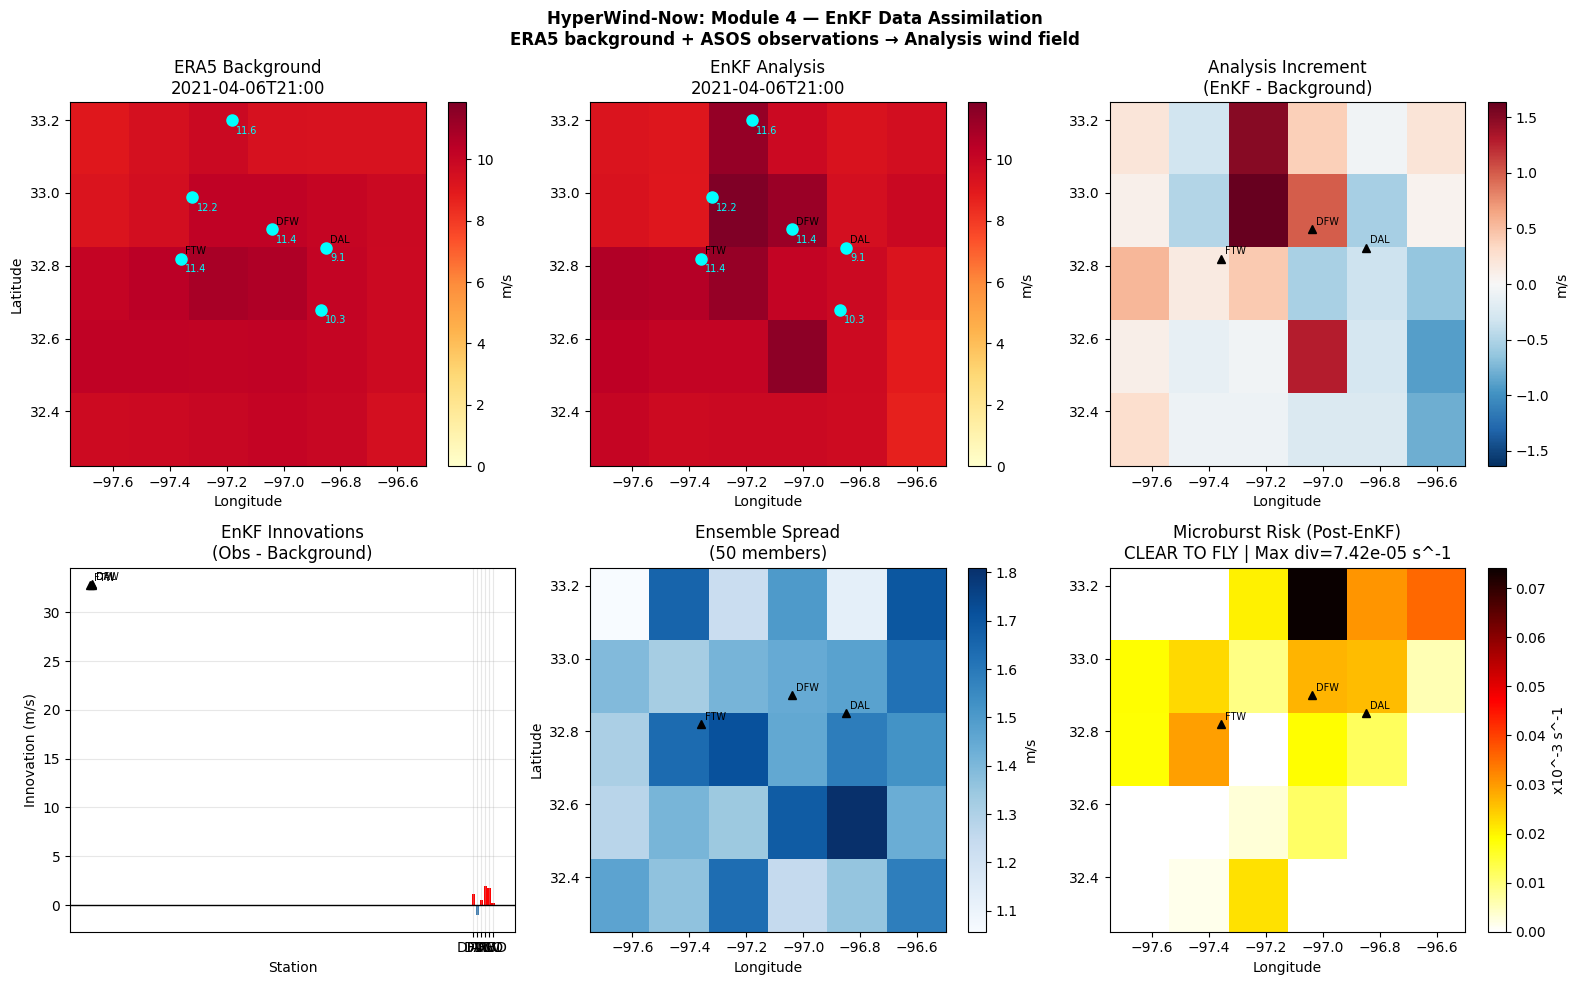

EnKF results saved!


In [22]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
extent = [LON.min(), LON.max(), LAT.min(), LAT.max()]
vmax   = max(ws_bg_grid.max(), ws_an_grid.max())

im0 = axes[0,0].imshow(ws_bg_grid, cmap="YlOrRd",
                        vmin=0, vmax=vmax,
                        origin="upper", extent=extent, aspect="auto")
plt.colorbar(im0, ax=axes[0,0], label="m/s")
axes[0,0].set_title(f"ERA5 Background\n{ts}")
axes[0,0].set_xlabel("Longitude")
axes[0,0].set_ylabel("Latitude")

im1 = axes[0,1].imshow(ws_an_grid, cmap="YlOrRd",
                        vmin=0, vmax=vmax,
                        origin="upper", extent=extent, aspect="auto")
plt.colorbar(im1, ax=axes[0,1], label="m/s")
axes[0,1].set_title(f"EnKF Analysis\n{ts}")
axes[0,1].set_xlabel("Longitude")

increment = ws_an_grid - ws_bg_grid
inc_max   = max(abs(increment).max(), 0.01)
im2 = axes[0,2].imshow(increment, cmap="RdBu_r",
                        vmin=-inc_max, vmax=inc_max,
                        origin="upper", extent=extent, aspect="auto")
plt.colorbar(im2, ax=axes[0,2], label="m/s")
axes[0,2].set_title("Analysis Increment\n(EnKF - Background)")
axes[0,2].set_xlabel("Longitude")

axes[1,0].bar(obs_stations, innov_ws,
              color=["red" if x > 0 else "steelblue"
                     for x in innov_ws])
axes[1,0].axhline(0, color="black", linewidth=1)
axes[1,0].set_xlabel("Station")
axes[1,0].set_ylabel("Innovation (m/s)")
axes[1,0].set_title("EnKF Innovations\n(Obs - Background)")
axes[1,0].grid(True, alpha=0.3)

ws_spread = ws_ensemble.std(axis=0).reshape(len(LAT), len(LON))
im4 = axes[1,1].imshow(ws_spread, cmap="Blues",
                        origin="upper", extent=extent, aspect="auto")
plt.colorbar(im4, ax=axes[1,1], label="m/s")
axes[1,1].set_title(f"Ensemble Spread\n({N_ENSEMBLE} members)")
axes[1,1].set_xlabel("Longitude")
axes[1,1].set_ylabel("Latitude")

risk     = np.clip(div_field * 1000, 0, None)
risk_max = max(risk.max(), 0.001)
im5 = axes[1,2].imshow(risk, cmap="hot_r",
                        vmin=0, vmax=risk_max,
                        origin="upper", extent=extent, aspect="auto")
plt.colorbar(im5, ax=axes[1,2], label="x10^-3 s^-1")
if alert:
    axes[1,2].scatter(mb_loc[1], mb_loc[0], s=400,
                      c="cyan", marker="*", zorder=5,
                      label="ALERT")
    axes[1,2].legend(fontsize=10)
axes[1,2].set_title(
    f"Microburst Risk (Post-EnKF)\n"
    f"{'WARNING' if alert else 'CLEAR TO FLY'} | "
    f"Max div={max_div:.2e} s^-1")
axes[1,2].set_xlabel("Longitude")

airports = {
    "DFW": (32.90, -97.04),
    "DAL": (32.85, -96.85),
    "FTW": (32.82, -97.36),
}
for name, (lat, lon) in airports.items():
    for ax in axes.flat:
        ax.plot(lon, lat, "^", color="black",
                markersize=6, zorder=5)
        ax.annotate(name, (lon, lat),
                    textcoords="offset points",
                    xytext=(3, 3), fontsize=7)

for name in obs_stations:
    s_lat, s_lon = STATIONS[name]
    for ax in [axes[0,0], axes[0,1]]:
        ax.plot(s_lon, s_lat, "o", color="cyan",
                markersize=8, zorder=6)
        ax.annotate(f"{station_obs[name]:.1f}",
                    (s_lon, s_lat),
                    textcoords="offset points",
                    xytext=(3, -10), fontsize=7,
                    color="cyan")

plt.suptitle(
    "HyperWind-Now: Module 4 — EnKF Data Assimilation\n"
    "ERA5 background + ASOS observations → Analysis wind field",
    fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "enkf_results.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("EnKF results saved!")